# Round 1 — Analysis v2 (Notebook)

Adapted from `analysis_v2.py`.


## 1. Imports & display config

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 300)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4.5)


## 2. Config

In [2]:
PRICE_FILES = [
    "prices_round_1_day_-2.csv",
    "prices_round_1_day_-1.csv",
    "prices_round_1_day_0.csv",
]

TRADE_FILES = [
    "trades_round_1_day_-2.csv",
    "trades_round_1_day_-1.csv",
    "trades_round_1_day_0.csv",
]

VISIBLE_LEVELS = 3
HORIZON = 10
PRODUCTS_FILTER = None   # e.g. ["RAINFOREST_RESIN"] to subset; None loads everything

DATA_DIR = os.path.join(os.getcwd(), "Data")
print("DATA_DIR:", DATA_DIR)


DATA_DIR: /Users/nickzhu/Desktop/NYU/2026 Spring/IMC Prosperity/imc_prosperity4/Round1/Data


## 3. Helper functions

In [3]:
def extract_day_from_filename(path: str) -> int:
    m = re.search(r"day_(-?\d+)", os.path.basename(path))
    return int(m.group(1)) if m else 0


def safe_corr(x, y):
    z = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(z) < 3:
        return np.nan
    if z["x"].std() == 0 or z["y"].std() == 0:
        return np.nan
    return z["x"].corr(z["y"])


def weighted_avg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights)
    if mask.sum() == 0:
        return np.nan
    values = values[mask]
    weights = weights[mask]
    if weights.sum() <= 0:
        return np.nan
    return np.sum(values * weights) / np.sum(weights)


def row_weighted_avg(row, price_cols, vol_cols):
    return weighted_avg([row[c] for c in price_cols], [row[c] for c in vol_cols])


def row_boundary_bid(row, bid_price_cols):
    vals = [row[c] for c in bid_price_cols if pd.notna(row[c])]
    return np.min(vals) if len(vals) > 0 else np.nan


def row_boundary_ask(row, ask_price_cols):
    vals = [row[c] for c in ask_price_cols if pd.notna(row[c])]
    return np.max(vals) if len(vals) > 0 else np.nan


def row_size_wall_price_and_volume(row, price_cols, vol_cols):
    """Size-wall = price level with largest displayed volume (frontier wins ties)."""
    best_idx, best_vol = None, -np.inf
    for i, vcol in enumerate(vol_cols):
        vol = row[vcol]
        if pd.notna(vol) and vol > best_vol:
            best_vol = vol
            best_idx = i
    if best_idx is None:
        return pd.Series([np.nan, np.nan])
    return pd.Series([row[price_cols[best_idx]], row[vol_cols[best_idx]]])


def next_trade_direction_from_price_vs_mid(price, mid):
    if pd.isna(price) or pd.isna(mid):
        return np.nan
    if price > mid:
        return 1
    if price < mid:
        return -1
    return 0


## 4. Load data

In [4]:
def load_prices(data_dir):
    dfs = []
    for fn in PRICE_FILES:
        df = pd.read_csv(os.path.join(data_dir, fn), sep=";")
        if "day" not in df.columns:
            df["day"] = extract_day_from_filename(fn)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)


def load_trades(data_dir):
    dfs = []
    for fn in TRADE_FILES:
        df = pd.read_csv(os.path.join(data_dir, fn), sep=";")
        if "day" not in df.columns:
            df["day"] = extract_day_from_filename(fn)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out.sort_values(["symbol", "day", "timestamp"]).reset_index(drop=True)


prices = load_prices(DATA_DIR)
trades = load_trades(DATA_DIR)

if PRODUCTS_FILTER is not None:
    prices = prices[prices["product"].isin(PRODUCTS_FILTER)].copy()
    trades = trades[trades["symbol"].isin(PRODUCTS_FILTER)].copy()

print(f"price rows: {len(prices):,}")
print(f"trade rows: {len(trades):,}")
print("products  :", sorted(prices["product"].dropna().unique()))
prices.head()


price rows: 60,000
trade rows: 2,276
products  : ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0


## 5. Feature engineering — order book

In [5]:
def build_book_features(prices):
    df = prices.copy()

    bid_price_cols = [f"bid_price_{i}"  for i in range(1, VISIBLE_LEVELS + 1)]
    bid_vol_cols   = [f"bid_volume_{i}" for i in range(1, VISIBLE_LEVELS + 1)]
    ask_price_cols = [f"ask_price_{i}"  for i in range(1, VISIBLE_LEVELS + 1)]
    ask_vol_cols   = [f"ask_volume_{i}" for i in range(1, VISIBLE_LEVELS + 1)]

    # Frontier (best prices)
    df["frontier_bid"] = df["bid_price_1"]
    df["frontier_ask"] = df["ask_price_1"]
    df["touch_mid"] = (df["frontier_bid"] + df["frontier_ask"]) / 2.0
    df["touch_spread"] = df["frontier_ask"] - df["frontier_bid"]
    df["dataset_mid_minus_touch_mid"] = df["mid_price"] - df["touch_mid"]

    # Boundary (outer visible edge)
    df["boundary_bid"] = df.apply(lambda r: row_boundary_bid(r, bid_price_cols), axis=1)
    df["boundary_ask"] = df.apply(lambda r: row_boundary_ask(r, ask_price_cols), axis=1)
    df["boundary_mid"] = (df["boundary_bid"] + df["boundary_ask"]) / 2.0
    df["boundary_width"] = df["boundary_ask"] - df["boundary_bid"]

    # Size-wall (largest-size level on each side)
    df[["size_wall_bid", "size_wall_bid_vol"]] = df.apply(
        lambda r: row_size_wall_price_and_volume(r, bid_price_cols, bid_vol_cols), axis=1)
    df[["size_wall_ask", "size_wall_ask_vol"]] = df.apply(
        lambda r: row_size_wall_price_and_volume(r, ask_price_cols, ask_vol_cols), axis=1)
    df["size_wall_mid"] = (df["size_wall_bid"] + df["size_wall_ask"]) / 2.0
    df["size_wall_width"] = df["size_wall_ask"] - df["size_wall_bid"]

    # VWAP centers
    df["bid_vwap_center"] = df.apply(lambda r: row_weighted_avg(r, bid_price_cols, bid_vol_cols), axis=1)
    df["ask_vwap_center"] = df.apply(lambda r: row_weighted_avg(r, ask_price_cols, ask_vol_cols), axis=1)
    df["side_vwap_mid"] = (df["bid_vwap_center"] + df["ask_vwap_center"]) / 2.0

    all_price_cols = bid_price_cols + ask_price_cols
    all_vol_cols   = bid_vol_cols + ask_vol_cols
    df["full_book_vwap_center"] = df.apply(
        lambda r: row_weighted_avg(r, all_price_cols, all_vol_cols), axis=1)

    # Depth / imbalance
    df["frontier_bid_vol"] = df["bid_volume_1"]
    df["frontier_ask_vol"] = df["ask_volume_1"]
    df["frontier_imbalance"] = (
        (df["frontier_bid_vol"] - df["frontier_ask_vol"]) /
        (df["frontier_bid_vol"] + df["frontier_ask_vol"]))
    df["bid_depth_total"] = df[bid_vol_cols].sum(axis=1, min_count=1)
    df["ask_depth_total"] = df[ask_vol_cols].sum(axis=1, min_count=1)
    df["depth_imbalance"] = (
        (df["bid_depth_total"] - df["ask_depth_total"]) /
        (df["bid_depth_total"] + df["ask_depth_total"]))
    df["size_wall_vol_imbalance"] = (
        (df["size_wall_bid_vol"] - df["size_wall_ask_vol"]) /
        (df["size_wall_bid_vol"] + df["size_wall_ask_vol"]))

    # Layer-2 dislocations
    fair_value_cols = [
        "touch_mid", "boundary_mid", "size_wall_mid",
        "side_vwap_mid", "full_book_vwap_center", "mid_price",
    ]
    for c in fair_value_cols:
        df[f"{c}_minus_touch_mid"] = df[c] - df["touch_mid"]
    df["boundary_minus_touch_width"] = df["boundary_width"] - df["touch_spread"]
    df["sizewall_minus_touch_width"] = df["size_wall_width"] - df["touch_spread"]
    df["side_vwap_skew"] = df["ask_vwap_center"] - df["bid_vwap_center"]

    # Forward price targets
    grp = df.groupby(["product", "day"])
    df[f"fwd_touch_mid_change_{HORIZON}"]   = grp["touch_mid"].shift(-HORIZON) - df["touch_mid"]
    df[f"fwd_dataset_mid_change_{HORIZON}"] = grp["mid_price"].shift(-HORIZON) - df["mid_price"]
    df[f"fwd_direction_{HORIZON}"] = np.where(
        df[f"fwd_touch_mid_change_{HORIZON}"] > 0, 1,
        np.where(df[f"fwd_touch_mid_change_{HORIZON}"] < 0, -1, 0))
    df[f"future_max_touch_mid_{HORIZON}"] = grp["touch_mid"].transform(
        lambda s: s.shift(-1).rolling(HORIZON, min_periods=1).max())
    df[f"future_min_touch_mid_{HORIZON}"] = grp["touch_mid"].transform(
        lambda s: s.shift(-1).rolling(HORIZON, min_periods=1).min())

    return df


book_df = build_book_features(prices)
print("book_df shape:", book_df.shape)
book_df.head()


book_df shape: (60000, 57)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,frontier_bid,frontier_ask,touch_mid,touch_spread,dataset_mid_minus_touch_mid,boundary_bid,boundary_ask,boundary_mid,boundary_width,size_wall_bid,size_wall_bid_vol,size_wall_ask,size_wall_ask_vol,size_wall_mid,size_wall_width,bid_vwap_center,ask_vwap_center,side_vwap_mid,full_book_vwap_center,frontier_bid_vol,frontier_ask_vol,frontier_imbalance,bid_depth_total,ask_depth_total,depth_imbalance,size_wall_vol_imbalance,touch_mid_minus_touch_mid,boundary_mid_minus_touch_mid,size_wall_mid_minus_touch_mid,side_vwap_mid_minus_touch_mid,full_book_vwap_center_minus_touch_mid,mid_price_minus_touch_mid,boundary_minus_touch_width,sizewall_minus_touch_width,side_vwap_skew,fwd_touch_mid_change_10,fwd_dataset_mid_change_10,fwd_direction_10,future_max_touch_mid_10,future_min_touch_mid_10
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,NaN,10010.0,NaN,NaN,NaN,NaN,10010.0,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,10010.000000,NaN,10010.000000,NaN,25.0,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.5,0,10000.0,10000.0
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,10000.0,16.0,0.0,9992.0,10011.0,10001.5,19.0,9992.0,15.0,10011.0,20.0,10001.5,19.0,9992.0,10009.714286,10000.857143,10004.400000,15.0,15.0,0.0,15.0,35.0,-0.4,-0.142857,0.0,1.5,1.5,0.857143,4.400000,0.0,3.0,3.0,17.714286,1.0,1.0,1,10000.0,10000.0
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,10000.0,16.0,0.0,9989.0,10010.0,9999.5,21.0,9989.0,30.0,10010.0,30.0,9999.5,21.0,9990.0,10009.333333,9999.666667,9999.666667,15.0,15.0,0.0,45.0,45.0,0.0,0.000000,0.0,-0.5,-0.5,-0.333333,-0.333333,0.0,5.0,5.0,19.333333,NaN,9.0,0,10000.0,10000.0
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,10000.0,16.0,0.0,9989.0,10010.0,9999.5,21.0,9989.0,26.0,10010.0,26.0,9999.5,21.0,9990.0,10009.333333,9999.666667,9999.666667,13.0,13.0,0.0,39.0,39.0,0.0,0.000000,0.0,-0.5,-0.5,-0.333333,-0.333333,0.0,5.0,5.0,19.333333,2.5,2.5,1,10000.0,10000.0
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,10000.0,16.0,0.0,9992.0,10010.0,10001.0,18.0,9992.0,15.0,10010.0,20.0,10001.0,18.0,9992.0,10009.142857,10000.571429,10004.000000,15.0,15.0,0.0,15.0,35.0,-0.4,-0.142857,0.0,1.0,1.0,0.571429,4.000000,0.0,2.0,2.0,17.142857,1.0,1.0,1,10000.0,10000.0


## 6. Feature engineering — trades, and merge

In [6]:
def build_trade_features(trades, book_df):
    trades = trades.copy()
    mini_book = book_df[[
        "product", "day", "timestamp", "touch_mid", "frontier_bid", "frontier_ask",
        "size_wall_bid", "size_wall_ask", "frontier_imbalance", "depth_imbalance",
        "size_wall_vol_imbalance",
    ]].copy()
    trades = trades.rename(columns={"symbol": "product"})
    trades = trades.merge(mini_book, on=["product", "day", "timestamp"], how="left")

    trades["trade_sign_proxy"] = trades.apply(
        lambda r: next_trade_direction_from_price_vs_mid(r["price"], r["touch_mid"]), axis=1)

    def classify_trade_location(row):
        if pd.isna(row["price"]):
            return "no_trade"
        p, bid1, ask1 = row["price"], row["frontier_bid"], row["frontier_ask"]
        bw, aw = row["size_wall_bid"], row["size_wall_ask"]
        if pd.notna(ask1) and p >= ask1: return "at_or_above_ask_touch"
        if pd.notna(bid1) and p <= bid1: return "at_or_below_bid_touch"
        if pd.notna(bid1) and pd.notna(ask1) and bid1 < p < ask1: return "inside_touch"
        if pd.notna(aw) and p >= aw: return "near_or_above_ask_wall"
        if pd.notna(bw) and p <= bw: return "near_or_below_bid_wall"
        return "other"

    trades["trade_location"] = trades.apply(classify_trade_location, axis=1)

    grouped = trades.groupby(["product", "day", "timestamp"], dropna=False)
    agg = grouped.apply(lambda g: pd.Series({
        "trade_count": len(g),
        "trade_volume": g["quantity"].sum(),
        "trade_vwap": weighted_avg(g["price"].to_numpy(), g["quantity"].to_numpy()),
        "trade_price_mean": g["price"].mean(),
        "trade_sign_proxy": np.sign(np.nansum(g["trade_sign_proxy"] * g["quantity"])),
        "frac_at_or_above_ask_touch": (g["trade_location"] == "at_or_above_ask_touch").mean(),
        "frac_at_or_below_bid_touch": (g["trade_location"] == "at_or_below_bid_touch").mean(),
        "frac_inside_touch": (g["trade_location"] == "inside_touch").mean(),
    })).reset_index()
    agg = agg.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)
    agg["next_trade_sign_proxy"] = agg.groupby(["product", "day"])["trade_sign_proxy"].shift(-1)
    return agg, trades


def merge_book_and_trade(book_df, trade_agg):
    df = book_df.merge(trade_agg, on=["product", "day", "timestamp"], how="left")
    for c in ["trade_count", "trade_volume", "frac_at_or_above_ask_touch",
              "frac_at_or_below_bid_touch", "frac_inside_touch"]:
        df[c] = df[c].fillna(0)
    df["trade_vwap_minus_touch_mid"]     = df["trade_vwap"] - df["touch_mid"]
    df["trade_vwap_minus_sizewall_mid"]  = df["trade_vwap"] - df["size_wall_mid"]
    return df


trade_agg, raw_trades = build_trade_features(trades, book_df)
df = merge_book_and_trade(book_df, trade_agg)
products = sorted(df["product"].dropna().unique())
print("merged df shape :", df.shape)
print("products        :", products)
print("horizon         :", HORIZON)


merged df shape : (60000, 68)
products        : ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
horizon         : 10


/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_9606/1909294158.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = grouped.apply(lambda g: pd.Series({


## 7. Pick a product to inspect

Change `PRODUCT` and re-run cells below.


In [7]:
PRODUCT = products[0]
PRODUCT


'ASH_COATED_OSMIUM'

## 8. Mid-price sanity check

Does the dataset's `mid_price` match `(bid_price_1 + ask_price_1) / 2`?


rows                                 : 30000
max abs difference                   : 0.000000000000
mean difference                      : 0.000000000000
std difference                       : 0.000000000000
fraction exactly zero                : 0.921467
fraction approximately zero (<1e-12) : 0.921467


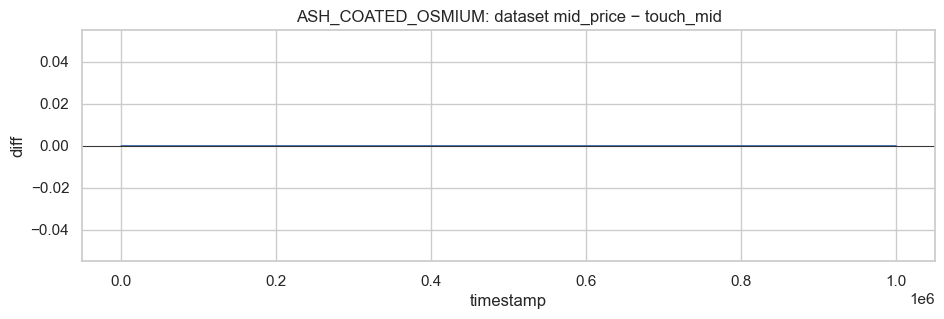

In [8]:
x = df[df["product"] == PRODUCT].copy()

print(f"rows                                 : {len(x)}")
print(f"max abs difference                   : {x['dataset_mid_minus_touch_mid'].abs().max():.12f}")
print(f"mean difference                      : {x['dataset_mid_minus_touch_mid'].mean():.12f}")
print(f"std difference                       : {x['dataset_mid_minus_touch_mid'].std():.12f}")
print(f"fraction exactly zero                : {(x['dataset_mid_minus_touch_mid'] == 0).mean():.6f}")
print(f"fraction approximately zero (<1e-12) : {(x['dataset_mid_minus_touch_mid'].abs() < 1e-12).mean():.6f}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(x["timestamp"].values, x["dataset_mid_minus_touch_mid"].values, lw=0.6)
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"{PRODUCT}: dataset mid_price − touch_mid")
ax.set_xlabel("timestamp"); ax.set_ylabel("diff")
plt.show()


## 9. Layer 1 — Static geometry

In [9]:
summary = {
    "touch_spread_mean": x["touch_spread"].mean(),
    "touch_spread_median": x["touch_spread"].median(),
    "boundary_width_mean": x["boundary_width"].mean(),
    "size_wall_width_mean": x["size_wall_width"].mean(),
    "frontier_imbalance_mean": x["frontier_imbalance"].mean(),
    "depth_imbalance_mean": x["depth_imbalance"].mean(),
    "size_wall_vol_imbalance_mean": x["size_wall_vol_imbalance"].mean(),
    "touch_mid_mean": x["touch_mid"].mean(),
    "boundary_mid_mean": x["boundary_mid"].mean(),
    "size_wall_mid_mean": x["size_wall_mid"].mean(),
    "side_vwap_mid_mean": x["side_vwap_mid"].mean(),
    "full_book_vwap_center_mean": x["full_book_vwap_center"].mean(),
    "dataset_mid_mean": x["mid_price"].mean(),
}
summary_df = pd.Series(summary).to_frame("value")
summary_df


,value
touch_spread_mean,16.175228
touch_spread_median,16.000000
boundary_width_mean,20.118796
size_wall_width_mean,20.117747
frontier_imbalance_mean,-0.001580
depth_imbalance_mean,-0.001366
size_wall_vol_imbalance_mean,-0.001809
touch_mid_mean,10000.209123
boundary_mid_mean,10000.222761
size_wall_mid_mean,10000.222598


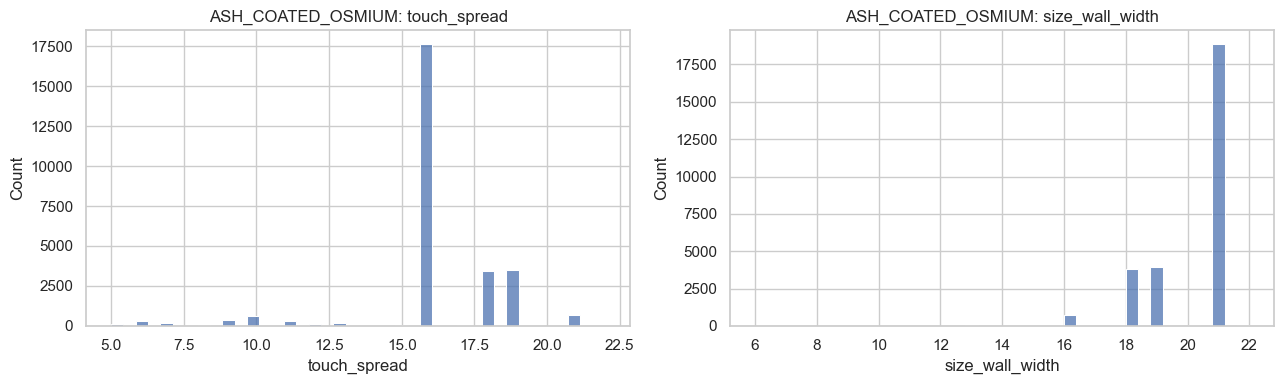

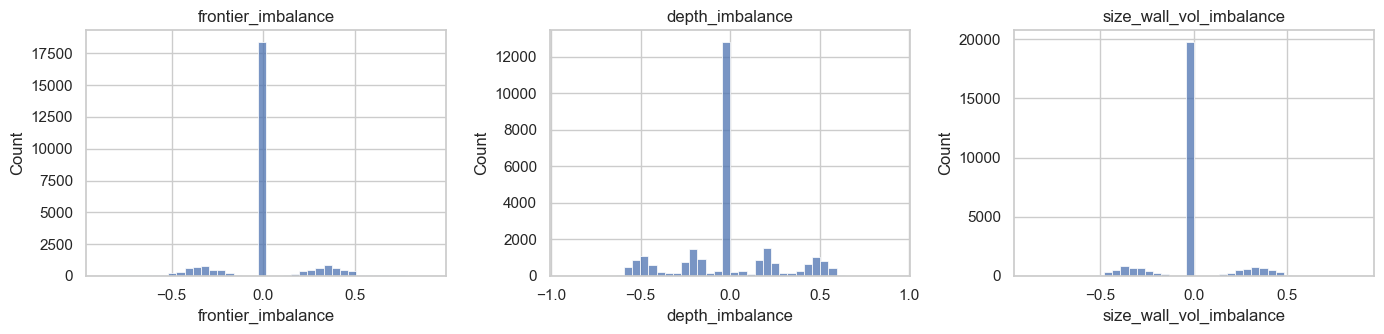

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(x["touch_spread"], bins=40, ax=axes[0]); axes[0].set_title(f"{PRODUCT}: touch_spread")
sns.histplot(x["size_wall_width"], bins=40, ax=axes[1]); axes[1].set_title(f"{PRODUCT}: size_wall_width")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
sns.histplot(x["frontier_imbalance"].dropna(), bins=40, ax=axes[0]);   axes[0].set_title("frontier_imbalance")
sns.histplot(x["depth_imbalance"].dropna(), bins=40, ax=axes[1]);      axes[1].set_title("depth_imbalance")
sns.histplot(x["size_wall_vol_imbalance"].dropna(), bins=40, ax=axes[2]); axes[2].set_title("size_wall_vol_imbalance")
plt.tight_layout(); plt.show()


## 10. Layer 2 — Fair-value correspondence & dislocations

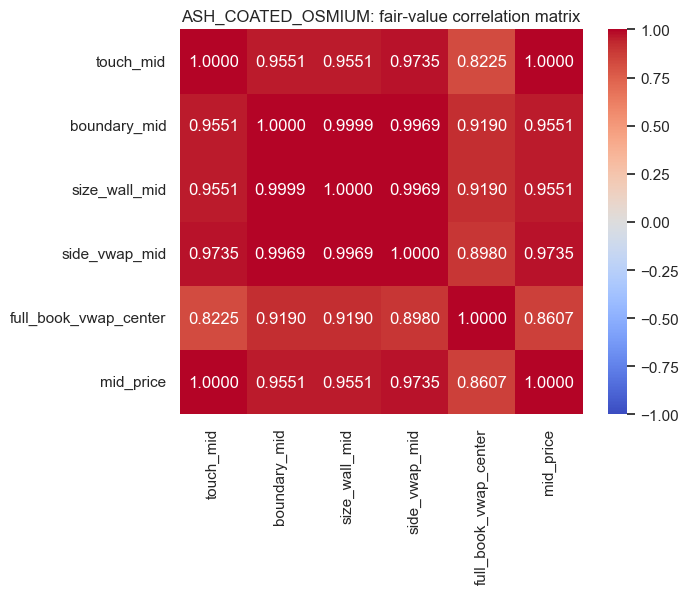

,touch_mid,boundary_mid,size_wall_mid,side_vwap_mid,full_book_vwap_center,mid_price
touch_mid,1.000000,0.955066,0.955094,0.973467,0.822463,1.000000
boundary_mid,0.955066,1.000000,0.999949,0.996904,0.918952,0.955066
size_wall_mid,0.955094,0.999949,1.000000,0.996900,0.918962,0.955094
side_vwap_mid,0.973467,0.996904,0.996900,1.000000,0.897995,0.973467
full_book_vwap_center,0.822463,0.918952,0.918962,0.897995,1.000000,0.860712
mid_price,1.000000,0.955066,0.955094,0.973467,0.860712,1.000000


In [11]:
fair_value_cols = [
    "touch_mid", "boundary_mid", "size_wall_mid",
    "side_vwap_mid", "full_book_vwap_center", "mid_price",
]
corr = x[fair_value_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title(f"{PRODUCT}: fair-value correlation matrix")
plt.show()
corr.round(6)


In [12]:
dislocation_cols = [
    "boundary_mid_minus_touch_mid",
    "size_wall_mid_minus_touch_mid",
    "side_vwap_mid_minus_touch_mid",
    "full_book_vwap_center_minus_touch_mid",
    "mid_price_minus_touch_mid",
    "boundary_minus_touch_width",
    "sizewall_minus_touch_width",
    "side_vwap_skew",
    "frontier_imbalance",
    "depth_imbalance",
    "size_wall_vol_imbalance",
]
disp = x[dislocation_cols].agg(["mean", "std", "min", "max"]).T
disp.round(6)


,mean,std,min,max
boundary_mid_minus_touch_mid,0.013638,1.444425,-6.000000,6.500000
size_wall_mid_minus_touch_mid,0.013475,1.443991,-6.000000,6.500000
side_vwap_mid_minus_touch_mid,0.013123,1.111696,-5.209302,5.827586
full_book_vwap_center_minus_touch_mid,0.024649,3.142605,-10.320755,10.357143
mid_price_minus_touch_mid,0.000000,0.000000,0.000000,0.000000
boundary_minus_touch_width,3.943568,2.745601,0.000000,16.000000
sizewall_minus_touch_width,3.942519,2.744690,0.000000,16.000000
side_vwap_skew,18.901666,1.311820,6.000000,22.000000
frontier_imbalance,-0.001580,0.233493,-0.875000,0.909091
depth_imbalance,-0.001366,0.272303,-0.913043,0.914894


## 11. Fair-value estimators vs future change

In [13]:
target = x[f"fwd_touch_mid_change_{HORIZON}"]
rows = []
for c in fair_value_cols:
    rows.append({
        "estimator": c,
        "mean": x[c].mean(),
        "std": x[c].std(),
        "mean_minus_touch_mid": (x[c] - x["touch_mid"]).mean(),
        "corr_with_future_change": safe_corr(x[c] - x["touch_mid"], target),
    })
fv_out = pd.DataFrame(rows)
fv_out.round(6)


,estimator,mean,std,mean_minus_touch_mid,corr_with_future_change
0,touch_mid,10000.209123,4.858191,0.000000,NaN
1,boundary_mid,10000.222761,4.753668,0.013638,0.530726
2,size_wall_mid,10000.222598,4.753838,0.013475,0.529799
3,side_vwap_mid,10000.222246,4.732245,0.013123,0.541563
4,full_book_vwap_center,10000.228357,6.032106,0.024649,0.267968
5,mid_price,9983.870567,403.865355,0.000000,NaN


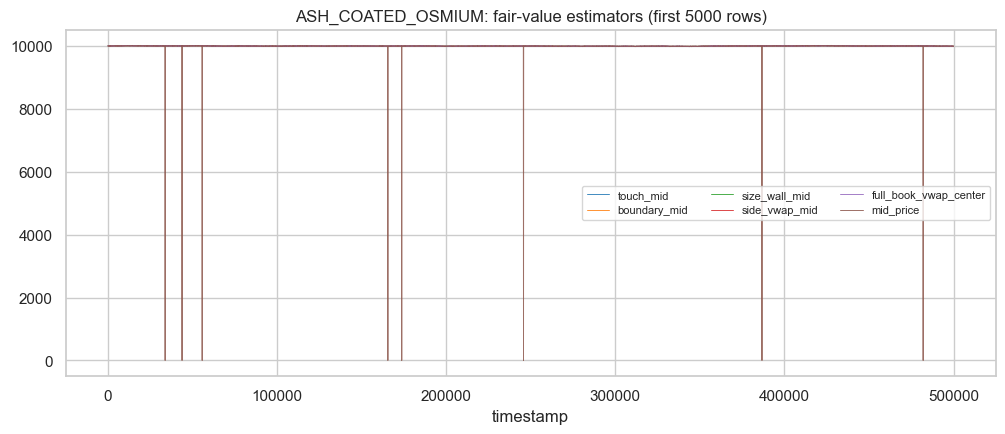

In [14]:
# Plot the five fair-value estimators over time (sample a slice to keep it readable)
sample = x.iloc[:5000]
fig, ax = plt.subplots(figsize=(12, 4.5))
for c, color in zip(fair_value_cols, sns.color_palette("tab10", n_colors=len(fair_value_cols))):
    ax.plot(sample["timestamp"].values, sample[c].values, label=c, lw=0.7, color=color, alpha=0.85)
ax.set_title(f"{PRODUCT}: fair-value estimators (first 5000 rows)")
ax.set_xlabel("timestamp"); ax.legend(ncol=3, fontsize=8)
plt.show()


## 12. Layer 3a — Predictive features for forward price change

In [15]:
target_change = x[f"fwd_touch_mid_change_{HORIZON}"]
target_dir    = x[f"fwd_direction_{HORIZON}"]

features = [
    "touch_spread", "boundary_width", "size_wall_width",
    "frontier_imbalance", "depth_imbalance", "size_wall_vol_imbalance",
    "boundary_mid_minus_touch_mid", "size_wall_mid_minus_touch_mid",
    "side_vwap_mid_minus_touch_mid", "full_book_vwap_center_minus_touch_mid",
    "trade_vwap_minus_touch_mid", "trade_count", "trade_volume", "trade_sign_proxy",
]

rows = []
for feat in features:
    rows.append({
        "feature": feat,
        f"corr_with_fwd_change_{HORIZON}":    safe_corr(x[feat], target_change),
        f"corr_with_fwd_direction_{HORIZON}": safe_corr(x[feat], target_dir),
    })
pred_out = pd.DataFrame(rows)
pred_out["abs_corr_change"] = pred_out[f"corr_with_fwd_change_{HORIZON}"].abs()
pred_out = pred_out.sort_values("abs_corr_change", ascending=False)
pred_out.round(6)


,feature,corr_with_fwd_change_10,corr_with_fwd_direction_10,abs_corr_change
8,side_vwap_mid_minus_touch_mid,0.541563,0.355561,0.541563
6,boundary_mid_minus_touch_mid,0.530726,0.357558,0.530726
7,size_wall_mid_minus_touch_mid,0.529799,0.357246,0.529799
3,frontier_imbalance,0.517746,0.418026,0.517746
9,full_book_vwap_center_minus_touch_mid,0.267968,0.197057,0.267968
4,depth_imbalance,-0.079143,-0.074642,0.079143
5,size_wall_vol_imbalance,0.070989,0.065907,0.070989
13,trade_sign_proxy,0.055051,0.042745,0.055051
0,touch_spread,-0.044624,-0.009026,0.044624
10,trade_vwap_minus_touch_mid,0.026679,0.031961,0.026679


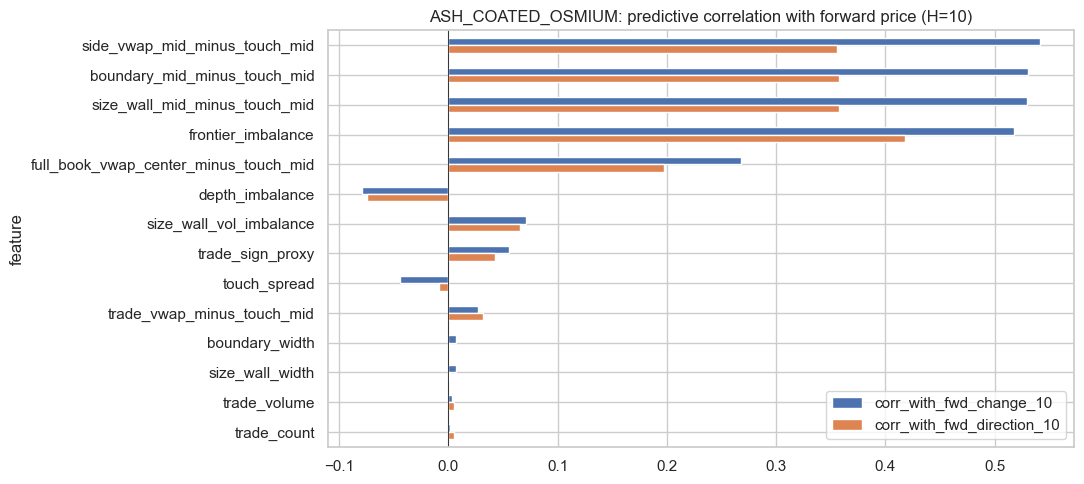

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = pred_out.set_index("feature")[[f"corr_with_fwd_change_{HORIZON}",
                                          f"corr_with_fwd_direction_{HORIZON}"]]
plot_df.plot(kind="barh", ax=ax)
ax.axvline(0, color="k", lw=0.6)
ax.set_title(f"{PRODUCT}: predictive correlation with forward price (H={HORIZON})")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 13. Layer 3b — Predictive features for next trade direction

/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_9606/3475763908.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ntd_out, y="feature", x="corr_with_next_trade_direction", ax=ax,


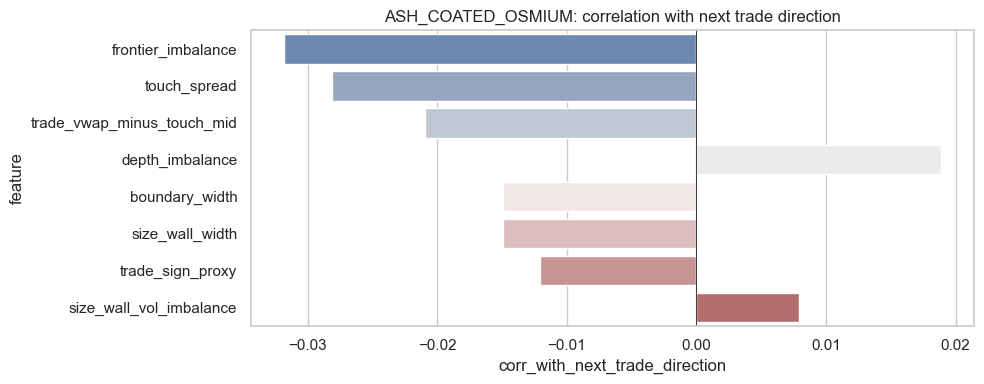

,feature,corr_with_next_trade_direction
0,frontier_imbalance,-0.031870
3,touch_spread,-0.028097
7,trade_vwap_minus_touch_mid,-0.020919
1,depth_imbalance,0.018877
4,boundary_width,-0.014923
5,size_wall_width,-0.014923
6,trade_sign_proxy,-0.012103
2,size_wall_vol_imbalance,0.007904


In [17]:
target_next_sign = x["next_trade_sign_proxy"]
features = [
    "frontier_imbalance", "depth_imbalance", "size_wall_vol_imbalance",
    "touch_spread", "boundary_width", "size_wall_width",
    "trade_sign_proxy", "trade_vwap_minus_touch_mid",
]
rows = [{"feature": f, "corr_with_next_trade_direction": safe_corr(x[f], target_next_sign)}
        for f in features]
ntd_out = (pd.DataFrame(rows)
           .sort_values("corr_with_next_trade_direction",
                        key=lambda s: s.abs(), ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=ntd_out, y="feature", x="corr_with_next_trade_direction", ax=ax,
            palette="vlag")
ax.axvline(0, color="k", lw=0.6)
ax.set_title(f"{PRODUCT}: correlation with next trade direction")
plt.tight_layout(); plt.show()
ntd_out.round(6)


## 14. Interaction A — Trade location vs book

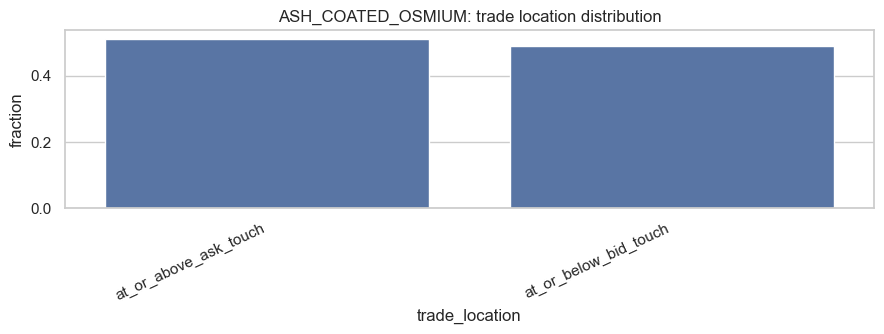

,count,fraction
trade_location,,
at_or_above_ask_touch,647,0.511462
at_or_below_bid_touch,618,0.488538


In [18]:
t = raw_trades[raw_trades["product"] == PRODUCT].copy()
loc = t["trade_location"].value_counts(dropna=False).to_frame("count")
loc["fraction"] = loc["count"] / loc["count"].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(x=loc.index, y=loc["fraction"].values, ax=ax)
ax.set_title(f"{PRODUCT}: trade location distribution")
ax.set_ylabel("fraction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()
loc.round(6)


## 15. Interaction B — Trade flow vs pre-trade imbalance

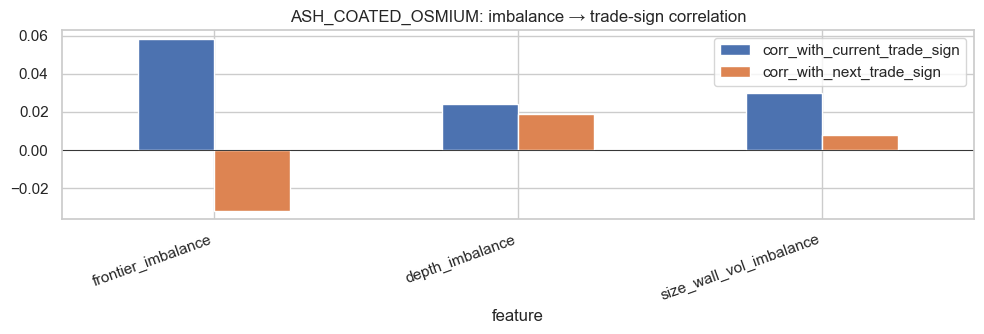

,feature,corr_with_current_trade_sign,corr_with_next_trade_sign
0,frontier_imbalance,0.058292,-0.031870
1,depth_imbalance,0.024140,0.018877
2,size_wall_vol_imbalance,0.029763,0.007904


In [19]:
xb = x.dropna(subset=["trade_sign_proxy", "frontier_imbalance", "depth_imbalance"])
rows = []
for feat in ["frontier_imbalance", "depth_imbalance", "size_wall_vol_imbalance"]:
    rows.append({
        "feature": feat,
        "corr_with_current_trade_sign": safe_corr(xb[feat], xb["trade_sign_proxy"]),
        "corr_with_next_trade_sign":    safe_corr(xb[feat], xb["next_trade_sign_proxy"]),
    })
B_out = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 3.5))
B_out.set_index("feature").plot(kind="bar", ax=ax)
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"{PRODUCT}: imbalance → trade-sign correlation")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
B_out.round(6)


## 16. Interaction C — Book depletion after trades

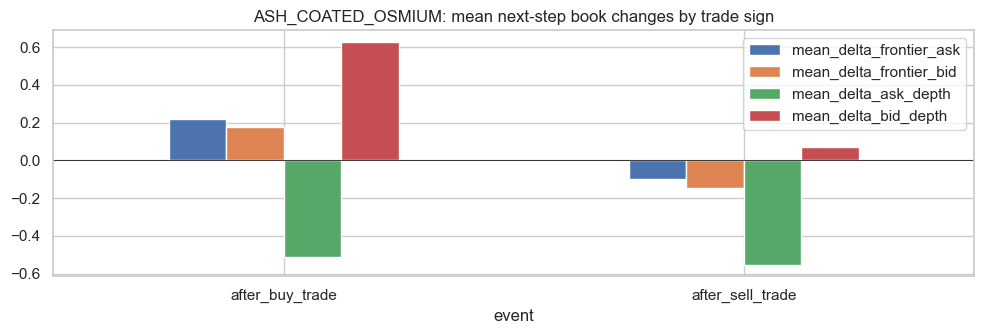

,event,mean_delta_frontier_ask,mean_delta_frontier_bid,mean_delta_ask_depth,mean_delta_bid_depth
0,after_buy_trade,0.220930,0.178037,-0.514950,0.628952
1,after_sell_trade,-0.098446,-0.145078,-0.554404,0.072539


In [20]:
xc = x.copy().sort_values(["day", "timestamp"])
xc["next_frontier_ask"] = xc.groupby(["product", "day"])["frontier_ask"].shift(-1)
xc["next_frontier_bid"] = xc.groupby(["product", "day"])["frontier_bid"].shift(-1)
xc["next_ask_depth"]    = xc.groupby(["product", "day"])["ask_depth_total"].shift(-1)
xc["next_bid_depth"]    = xc.groupby(["product", "day"])["bid_depth_total"].shift(-1)

xc["delta_frontier_ask"] = xc["next_frontier_ask"] - xc["frontier_ask"]
xc["delta_frontier_bid"] = xc["next_frontier_bid"] - xc["frontier_bid"]
xc["delta_ask_depth"]    = xc["next_ask_depth"]    - xc["ask_depth_total"]
xc["delta_bid_depth"]    = xc["next_bid_depth"]    - xc["bid_depth_total"]

buy_rows  = xc[xc["trade_sign_proxy"] > 0]
sell_rows = xc[xc["trade_sign_proxy"] < 0]
C_out = pd.DataFrame([
    {"event": "after_buy_trade",
     "mean_delta_frontier_ask": buy_rows["delta_frontier_ask"].mean(),
     "mean_delta_frontier_bid": buy_rows["delta_frontier_bid"].mean(),
     "mean_delta_ask_depth":    buy_rows["delta_ask_depth"].mean(),
     "mean_delta_bid_depth":    buy_rows["delta_bid_depth"].mean()},
    {"event": "after_sell_trade",
     "mean_delta_frontier_ask": sell_rows["delta_frontier_ask"].mean(),
     "mean_delta_frontier_bid": sell_rows["delta_frontier_bid"].mean(),
     "mean_delta_ask_depth":    sell_rows["delta_ask_depth"].mean(),
     "mean_delta_bid_depth":    sell_rows["delta_bid_depth"].mean()},
])

fig, ax = plt.subplots(figsize=(10, 3.5))
C_out.set_index("event").plot(kind="bar", ax=ax)
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"{PRODUCT}: mean next-step book changes by trade sign")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
C_out.round(6)


## 17. Interaction D — Break vs bounce at size-wall

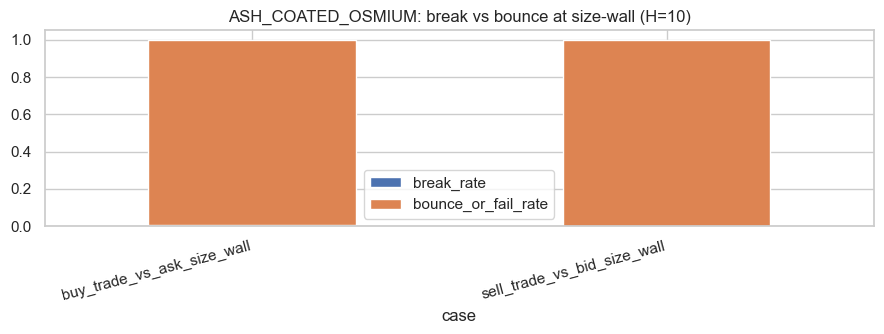

,case,count,break_rate,bounce_or_fail_rate
0,buy_trade_vs_ask_size_wall,622,0.004823,0.995177
1,sell_trade_vs_bid_size_wall,594,0.001684,0.998316


In [21]:
buy_test = x[x["trade_sign_proxy"] > 0].copy()
buy_test["break_up"] = buy_test[f"future_max_touch_mid_{HORIZON}"] > buy_test["size_wall_ask"]
buy_test["bounce_or_fail"] = ~buy_test["break_up"]

sell_test = x[x["trade_sign_proxy"] < 0].copy()
sell_test["break_down"] = sell_test[f"future_min_touch_mid_{HORIZON}"] < sell_test["size_wall_bid"]
sell_test["bounce_or_fail"] = ~sell_test["break_down"]

D_out = pd.DataFrame([
    {"case": "buy_trade_vs_ask_size_wall",
     "count": len(buy_test),
     "break_rate": buy_test["break_up"].mean() if len(buy_test) > 0 else np.nan,
     "bounce_or_fail_rate": buy_test["bounce_or_fail"].mean() if len(buy_test) > 0 else np.nan},
    {"case": "sell_trade_vs_bid_size_wall",
     "count": len(sell_test),
     "break_rate": sell_test["break_down"].mean() if len(sell_test) > 0 else np.nan,
     "bounce_or_fail_rate": sell_test["bounce_or_fail"].mean() if len(sell_test) > 0 else np.nan},
])

fig, ax = plt.subplots(figsize=(9, 3.5))
D_out.set_index("case")[["break_rate", "bounce_or_fail_rate"]].plot(kind="bar", ax=ax, stacked=True)
ax.set_title(f"{PRODUCT}: break vs bounce at size-wall (H={HORIZON})")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()
D_out.round(6)


## 18. Interaction E — Trade-informed future targets & adverse selection

/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_9606/1170312900.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matrix = valid.groupby(["trade_sign_proxy", "wall_imb_bucket"]).agg(


count  avg_future_change   prob_up  prob_down
trade_sign_proxy wall_imb_bucket                                               
-1.0             (-0.853, 0.0]      485          -0.072165  0.402062   0.410309
                 (0.0, 0.568]        71          -0.218310  0.394366   0.450704
 1.0             (-0.853, 0.0]      498           0.041165  0.437751   0.389558
                 (0.0, 0.568]        76           0.769737  0.486842   0.302632

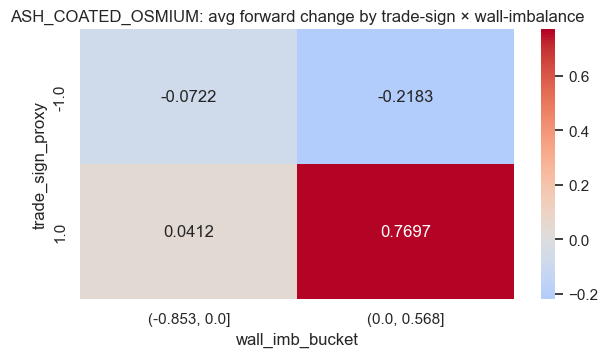

In [22]:
valid = x.dropna(subset=["trade_sign_proxy", "size_wall_vol_imbalance",
                           f"fwd_touch_mid_change_{HORIZON}"]).copy()

if len(valid) >= 20:
    valid["wall_imb_bucket"] = pd.qcut(valid["size_wall_vol_imbalance"], q=3, duplicates="drop")
    matrix = valid.groupby(["trade_sign_proxy", "wall_imb_bucket"]).agg(
        count=(f"fwd_touch_mid_change_{HORIZON}", "size"),
        avg_future_change=(f"fwd_touch_mid_change_{HORIZON}", "mean"),
        prob_up=(f"fwd_touch_mid_change_{HORIZON}", lambda s: (s > 0).mean()),
        prob_down=(f"fwd_touch_mid_change_{HORIZON}", lambda s: (s < 0).mean()),
    )
    display(matrix.round(6))

    heat = matrix["avg_future_change"].unstack("wall_imb_bucket")
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.heatmap(heat, annot=True, fmt=".4f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"{PRODUCT}: avg forward change by trade-sign × wall-imbalance")
    plt.show()
else:
    print("Not enough rows for matrix")


In [23]:
buy_rows  = x[x["trade_sign_proxy"] > 0]
sell_rows = x[x["trade_sign_proxy"] < 0]
buy_adverse  = (buy_rows[f"fwd_touch_mid_change_{HORIZON}"] < 0).mean() if len(buy_rows)  else np.nan
sell_adverse = (sell_rows[f"fwd_touch_mid_change_{HORIZON}"] > 0).mean() if len(sell_rows) else np.nan

adverse = pd.DataFrame([
    {"case": "after_buy_trade",  "count": len(buy_rows),
     f"adverse_selection_rate_{HORIZON}": buy_adverse},
    {"case": "after_sell_trade", "count": len(sell_rows),
     f"adverse_selection_rate_{HORIZON}": sell_adverse},
])
adverse.round(6)


,case,count,adverse_selection_rate_10
0,after_buy_trade,622,0.348875
1,after_sell_trade,594,0.375421


## 19. (Optional) Loop over all products

Quick batch view — per-product corr of frontier imbalance vs forward direction.


In [24]:
results = []
for p in products:
    xp = df[df["product"] == p]
    results.append({
        "product": p,
        "rows": len(xp),
        "corr_frontier_imb_vs_fwd_dir":
            safe_corr(xp["frontier_imbalance"], xp[f"fwd_direction_{HORIZON}"]),
        "corr_depth_imb_vs_fwd_dir":
            safe_corr(xp["depth_imbalance"], xp[f"fwd_direction_{HORIZON}"]),
        "corr_sizewall_imb_vs_fwd_dir":
            safe_corr(xp["size_wall_vol_imbalance"], xp[f"fwd_direction_{HORIZON}"]),
    })
pd.DataFrame(results).round(6)


,product,rows,corr_frontier_imb_vs_fwd_dir,corr_depth_imb_vs_fwd_dir,corr_sizewall_imb_vs_fwd_dir
0,ASH_COATED_OSMIUM,30000,0.418026,-0.074642,0.065907
1,INTARIAN_PEPPER_ROOT,30000,0.471633,-0.100162,0.089026
